In [1]:
import numpy as np
import pandas as pd
import random
from chemevo import evolution_V1 as evo1
from chemevo import evolution_V3 as evo3
import itertools
import os
import matplotlib.pyplot as plt

mg_h_big_bin_edges = np.arange(-0.7, 0.50, 0.20) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])


# A few SFRS
t_array = np.linspace(0.0001,14,int(1e3))
t_array_big = np.linspace(0.0001,14,int(1e2))
def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)

m_g_array_rise_fall_1 = rise_fall(t_array, 2, 8)
m_g_array_rise_fall_1 /= np.trapezoid(m_g_array_rise_fall_1, t_array)

In [2]:
sfr = m_g_array_rise_fall_1
tau_star = 2
eta = 0
g_ratio = 2
g_cc = 0.4
alpha_Ia = 0.6
alpha_cc = 0.3

In [3]:
# evo1 is fast version
example_gal_evo1 = evo1.Galaxy(
                t_array=t_array, m_g_array=sfr, tau_star=tau_star,
                eta=eta, Upsilon=1, yields_ref="W2024,moreFe",
                g_cc_Mn=g_cc, g_ratio_Mn=g_ratio,
                alpha_cc_Mn=alpha_cc, alpha_Ia_Mn=alpha_Ia)

# evo3 is slow version
example_gal_evo3 = evo3.Galaxy(
                t_array=t_array, m_g_array=sfr, tau_star=tau_star,
                eta=eta, Upsilon=1, yields_ref="W2024,moreFe",
                g_cc_Mn=g_cc, g_ratio_Mn=g_ratio,
                alpha_cc_Mn=alpha_cc, alpha_Ia_Mn=alpha_Ia)

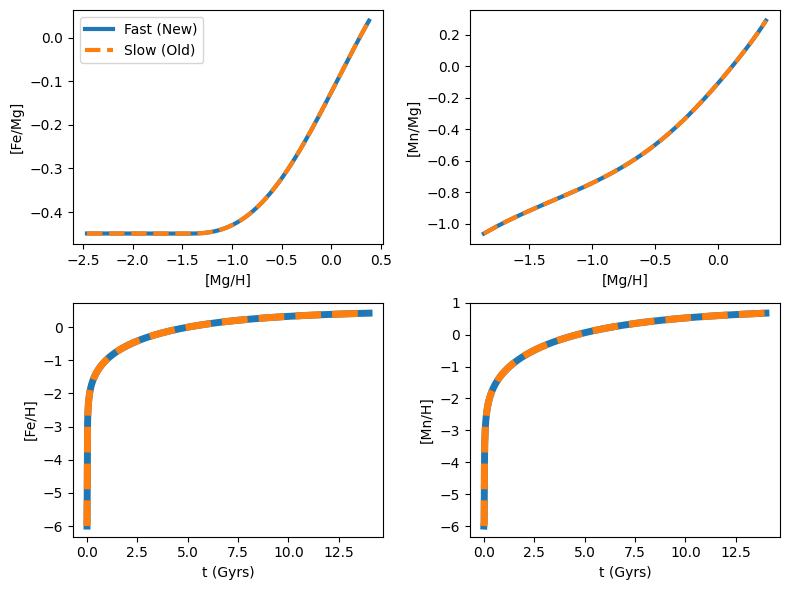

In [4]:
plt.figure(figsize=(8,6))

plt.subplot(2,2,1)
plt.plot(example_gal_evo1.Mg_H[2:], example_gal_evo1.Fe_Mg[2:], linewidth = 3, label = 'Fast (New)')
plt.plot(example_gal_evo3.Mg_H[2:], example_gal_evo3.Fe_Mg[2:], linewidth = 3, linestyle = '--', label = 'Slow (Old)')
plt.xlabel("[Mg/H]")
plt.ylabel("[Fe/Mg]")
plt.legend()

plt.subplot(2,2,2)
plt.plot(example_gal_evo1.Mg_H[5:], example_gal_evo1.Mn_Mg[5:], linewidth = 3)
plt.plot(example_gal_evo3.Mg_H[5:], example_gal_evo3.Mn_Mg[5:], linestyle = '--', linewidth = 3)
plt.xlabel("[Mg/H]")
plt.ylabel("[Mn/Mg]")

plt.subplot(2,2,3)
plt.plot(t_array, example_gal_evo1.Fe_H, linewidth = 5)
plt.plot(t_array, example_gal_evo3.Fe_H, linestyle = '--', linewidth = 5)
plt.xlabel("t (Gyrs)")
plt.ylabel("[Fe/H]")

plt.subplot(2,2,4)
plt.plot(t_array, example_gal_evo1.Mn_H, linewidth = 5)
plt.plot(t_array, example_gal_evo3.Mn_H, linestyle = '--', linewidth = 5)
plt.xlabel("t (Gyrs)")
plt.ylabel("[Mn/H]")


plt.tight_layout()

In [5]:
example_gal_bigdt = evo1.Galaxy(
                t_array=t_array_big, m_g_array=rise_fall(t_array_big, 2, 8), tau_star=tau_star,
                eta=eta, Upsilon=1, yields_ref="W2024,moreFe",
                g_cc_Mn=g_cc, g_ratio_Mn=g_ratio,
                alpha_cc_Mn=alpha_cc, alpha_Ia_Mn=alpha_Ia)

example_gal_smalldt = evo1.Galaxy(
                t_array=t_array, m_g_array=sfr, tau_star=tau_star,
                eta=eta, Upsilon=1, yields_ref="W2024,moreFe",
                g_cc_Mn=g_cc, g_ratio_Mn=g_ratio,
                alpha_cc_Mn=alpha_cc, alpha_Ia_Mn=alpha_Ia)

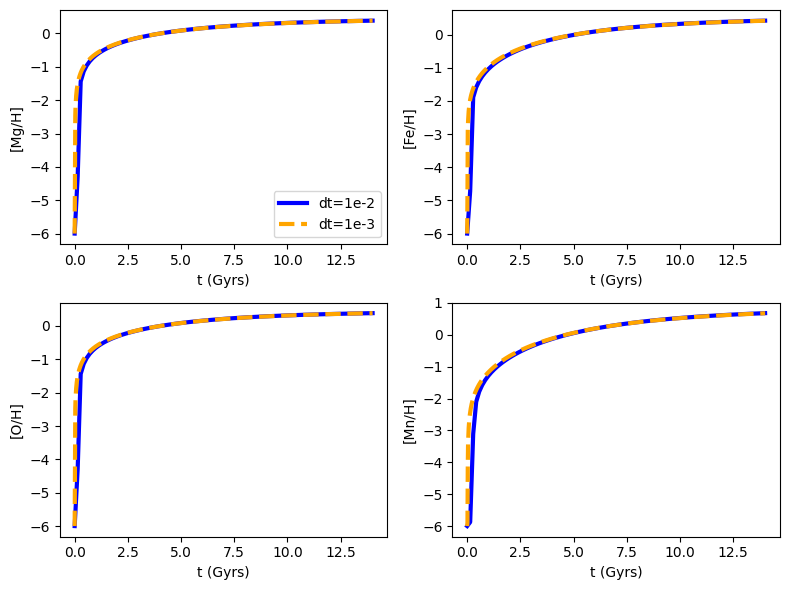

In [16]:
plt.figure(figsize=(8,6))

plt.subplot(2,2,1)
plt.plot(example_gal_bigdt.t, example_gal_bigdt.Mg_H, label = 'dt=1e-2', linewidth = 3, color = 'blue')
plt.plot(example_gal_smalldt.t, example_gal_smalldt.Mg_H, label = 'dt=1e-3', linestyle = '--', linewidth = 3, color = 'orange')
plt.xlabel("t (Gyrs)")
plt.ylabel("[Mg/H]")
plt.legend()

plt.subplot(2,2,2)
plt.plot(example_gal_bigdt.t, example_gal_bigdt.Fe_H, label = 'dt=1e-2', linewidth = 3, color = 'blue')
plt.plot(example_gal_smalldt.t, example_gal_smalldt.Fe_H, label = 'dt=1e-3', linestyle = '--', linewidth = 3, color = 'orange')
plt.xlabel("t (Gyrs)")
plt.ylabel("[Fe/H]")

plt.subplot(2,2,3)
plt.plot(example_gal_bigdt.t, example_gal_bigdt.O_H, label = 'dt=1e-2', linewidth = 3, color = 'blue')
plt.plot(example_gal_smalldt.t, example_gal_smalldt.O_H, label = 'dt=1e-3', linestyle = '--', linewidth = 3, color = 'orange')
plt.xlabel("t (Gyrs)")
plt.ylabel("[O/H]")

plt.subplot(2,2,4)
plt.plot(example_gal_bigdt.t, example_gal_bigdt.Mn_H, label = 'dt=1e-2', linewidth = 3, color = 'blue')
plt.plot(example_gal_smalldt.t, example_gal_smalldt.Mn_H, label = 'dt=1e-3', linestyle = '--', linewidth = 3, color = 'orange')
plt.xlabel("t (Gyrs)")
plt.ylabel("[Mn/H]")


plt.tight_layout()

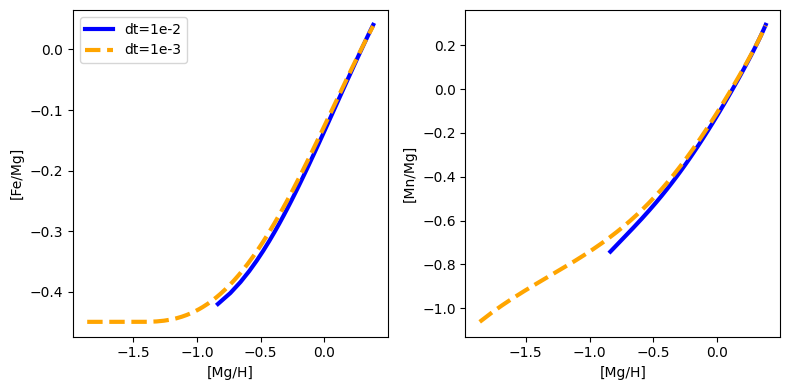

In [19]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.plot(example_gal_bigdt.Mg_H[5:], example_gal_bigdt.Fe_Mg[5:], label = 'dt=1e-2', linewidth = 3, color = 'blue')
plt.plot(example_gal_smalldt.Mg_H[5:], example_gal_smalldt.Fe_Mg[5:], label = 'dt=1e-3', linestyle = '--', linewidth = 3, color = 'orange')
plt.xlabel("[Mg/H]")
plt.ylabel("[Fe/Mg]")
plt.legend()

plt.subplot(1,2,2)
plt.plot(example_gal_bigdt.Mg_H[5:], example_gal_bigdt.Mn_Mg[5:], label = 'dt=1e-2', linewidth = 3, color = 'blue')
plt.plot(example_gal_smalldt.Mg_H[5:], example_gal_smalldt.Mn_Mg[5:], label = 'dt=1e-3', linestyle = '--', linewidth = 3, color = 'orange')
plt.xlabel("[Mg/H]")
plt.ylabel("[Mn/Mg]")


plt.tight_layout()